# Dev / test notebook for adapting DEAR codebase


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import logging
import torch 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.data_utils as dut
import src.plotting as splo

import src.dear.utils as sdu
import src.dear.data as sdd
from src.dear.model import BGM, BigJointDiscriminator

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data'
res_path = '../results/xView_0_fix/'

In [4]:
to_di = lambda x: dict( [y.split(':') for y in x.split('\t')[-1].split(',')])

rename_di = {
    'D loss' : 'disc',
    ' Encoder loss' : 'enc',
    ' Decoder loss' : 'dec',
    ' Sup loss' : 'sup',
    ' E_score' : 'enc_',
    ' D score' : 'dec_'
}

def parse_log( log_path):
    log_lines = dut.to_from_text( log_path).split('\n')
    df = pd.DataFrame([to_di(y) for y in log_lines[:-1]]).astype(float)
    df.rename( columns= rename_di, inplace= True)
    return df

In [5]:
# map names of the causal nodes to the index of the column in label.csv file
labels_index_di = {
    'buildings': 2,
    'roads': 3,
    'cars': 4,
}
labels_ordered = ['buildings','roads','cars']
# provide the causal structure as tuples of (parent,child)
causal_ordering = [
    ('buildings','roads'),
    ('roads','cars'),
    ('buildings','cars')
]

def adjacency_from_tuples( causal_ordering, labels_ordered):
    """
    NOTE: this returns the *transpose* of adjacency matrix, as this is what the DEAR framework 
    uses as input format; they refer to it as A, but typical causal notation is A_T, hence our notation.
    """
    n_nodes = len( labels_ordered)
    labels_enum_di =  dict(zip( labels_ordered, range( n_nodes)))
    A_T = torch.zeros( (n_nodes, n_nodes))
    for parent, child in causal_ordering:
        parent_id, child_id = labels_enum_di[ parent], labels_enum_di[ child]
        A_T[ parent_id, child_id] = 1
    return A_T

adjacency_from_tuples( causal_ordering, labels_ordered)

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])

In [6]:
get_name_from_batch = lambda x: f'model{x}.sav'
get_batch_from_name = lambda x: int( x.split('.sav')[0].split('model')[-1])
device = sdu.get_device()

def load_dear_config( config_path):
    # DEAR-main config is just a plain-text file..
    # TODO: amend
    config_lines = dut.to_from_text( config_path).split('\n')[:-1]
    values = []
    for v in [x.split(':')[1].strip() for x in config_lines]:
        try:
            v = int(v)
        except ValueError:
            try:
                v = float(v)
            except ValueError:
                pass
        values.append(v)
    return dict(zip([x.split(':')[0].strip() for x in config_lines], values))

def load_from_checkpoint( folder, checkpoint= None, with_disc= False):
    # need to know the configuration:
    config_path = f'{folder}config.txt'
    # and need an existing checkpoint:
    if checkpoint is None:
        checkpoints_at = [get_batch_from_name(x) for x in os.listdir( folder) if x.endswith('.sav')]
        checkpoint = get_name_from_batch( max( checkpoints_at))
    elif type(checkpoint) == int:
        checkpoint = get_name_from_batch( checkpoint)
    checkpoint_path = f'{folder}{checkpoint}'
    assert os.path.exists( checkpoint_path)
    
    # load config for initialising the architecture correctly:
    config_dict = load_dear_config( config_path)
    
    # TODO: remove hard-coding!!!
    # TODO: make an option for no causal prior
    A_init = torch.load( '../data/xView_0/A_T.pt')
    n_nodes, _ = A_init.shape
    model = BGM( 
        config_dict['latent_dim'], config_dict['g_conv_dim'], config_dict['image_size'],
        config_dict['enc_dist'], config_dict['enc_arch'], config_dict['enc_fc_size'], config_dict['enc_noise_dim'],
        config_dict['dec_dist'], config_dict['prior'], n_nodes, A_init
    )
    checkpoint_data = torch.load( checkpoint_path, map_location= device)
    model.load_state_dict( checkpoint_data[ 'model'])
    if with_disc:
        discriminator = BigJointDiscriminator( 
            config_dict['latent_dim'], config_dict['d_conv_dim'], config_dict['image_size'], config_dict['dis_fc_size']
        )
        discriminator.load_state_dict( checkpoint_data[ 'discriminator'])
        
    else:
        discriminator = None
    
    del checkpoint_data
    print(f'Loaded model from {checkpoint_path}')
    return config_dict, model, discriminator

In [64]:
def plot_adjacency_matrix( adj_mat_numpy, labels_ordered):
    scale = int( np.ceil( ( abs(adj_mat_numpy)).max()))
    _, ax = plt.subplots( figsize= (3,3))
    ax.matshow( adj_mat_numpy, cmap= 'coolwarm', vmin= -scale, vmax= scale)
    ax.set_xticks([0,1,2], labels_ordered)
    ax.set_yticks([0,1,2], labels_ordered)

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [7]:
os.listdir(res_path)

['config.txt', 'log.txt', 'model200.sav']

In [8]:
log_path = f'{res_path}log.txt'

In [9]:
df = parse_log( log_path)
df.head(3)

,disc,enc,dec,sup,enc_,dec_
0,1.5114,1.1393,0.5621,0.7478,0.3915,-1.1242
1,0.8469,0.9459,0.7265,0.4608,0.4851,-1.4530
2,0.1086,2.9885,2.1502,0.5340,2.4545,-4.3004


<Axes: >

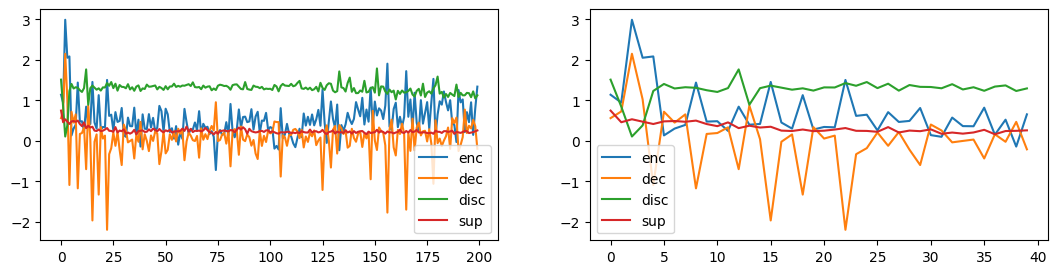

In [10]:
_, axs = plt.subplots( ncols= 2, figsize= (13,3))
df[['enc','dec','disc','sup']].plot( ax= axs[0])
df[['enc','dec','disc','sup']].head(40).plot( ax= axs[1])

### something else...

In [11]:
config_dict, model, _ = load_from_checkpoint( res_path)
config_dict['dataset'], config_dict['data_dir']

Loaded model from ../results/xView_0_fix/model200.sav


('xView_0_fix', '../data/xView_0_fix')

<Axes: >

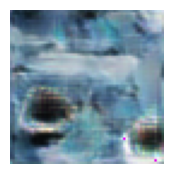

In [15]:
latent_ = torch.randn( 4, config_dict['latent_dim'], device= device)
gen_images = model( z= latent_).cpu()

splo.plot_single( (dut.to_numpy(gen_images[1].detach())*255).astype(np.uint8), figsize= (2,2))

<Axes: >

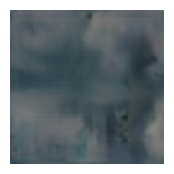

In [21]:

splo.plot_single( ( dut.to_numpy(sdu.denorm( gen_images[0].detach()))*255).astype(np.uint8), figsize= (2,2))

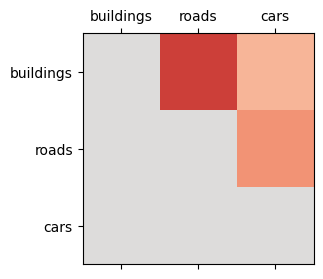

In [66]:
plot_adjacency_matrix( model.prior.A.detach().numpy(), labels_ordered)